# 00: What Would Digital Life Mean?

This laboratory introduction turns the chapter's method into executable habits: define the mechanism, expose configuration, observe, measure, compare, and keep the claim bounded.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


## Question from the chapter

How can we study life-like claims without smuggling them into class names or screenshots?


In [2]:
EXPERIMENT = {"rule": 22, "width": 81, "generations": 41, "seed": "single active center cell", "boundary": "periodic"}
EXPERIMENT


{'rule': 22,
 'width': 81,
 'generations': 41,
 'seed': 'single active center cell',
 'boundary': 'periodic'}

## Build the minimum system

An elementary cellular automaton has binary state, a three-cell neighborhood, one eight-bit rule, synchronous update, and a boundary condition.


In [3]:
def elementary_step(state: np.ndarray, rule: int) -> np.ndarray:
    left = np.roll(state, 1)
    centre = state
    right = np.roll(state, -1)
    neighborhood = (left << 2) | (centre << 1) | right
    return ((rule >> neighborhood) & 1).astype(np.uint8)


def single_seed(width: int) -> np.ndarray:
    state = np.zeros(width, dtype=np.uint8)
    state[width // 2] = 1
    return state


def run_rule(rule: int, width: int, generations: int, initial_state=None) -> np.ndarray:
    state = single_seed(width) if initial_state is None else initial_state.astype(np.uint8).copy()
    history = np.zeros((generations, width), dtype=np.uint8)
    history[0] = state
    for t in range(1, generations):
        state = elementary_step(state, rule)
        history[t] = state
    return history


def show_spacetime(history, title, path=None, figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(history, cmap="binary", interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Space")
    ax.set_ylabel("Time")
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    plt.show()


## Baseline observation


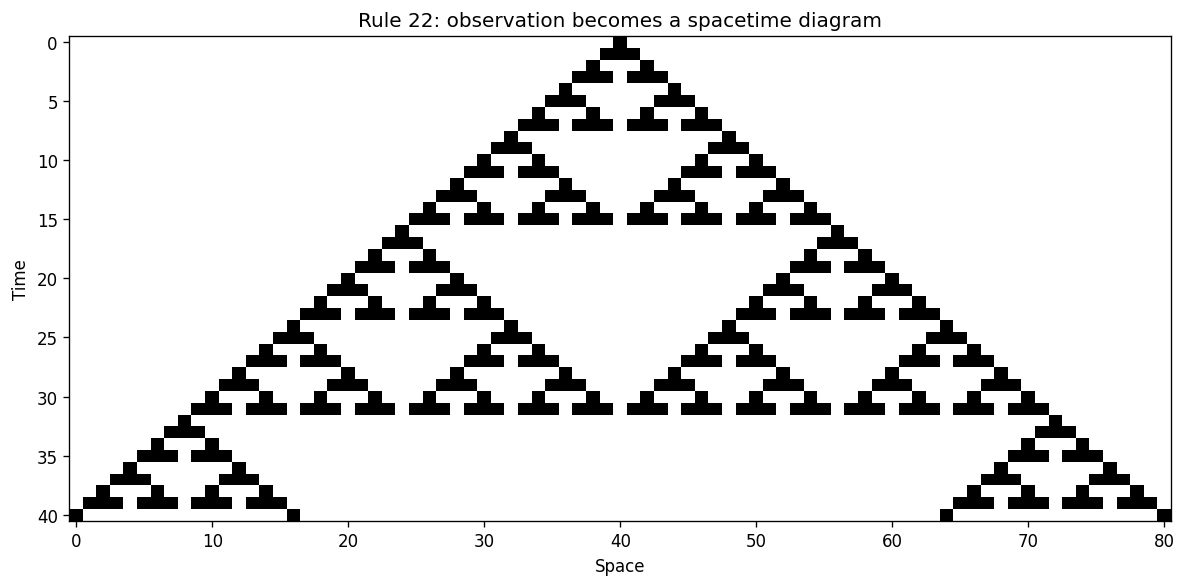

In [4]:
history = run_rule(**{k: EXPERIMENT[k] for k in ("rule", "width", "generations")})
show_spacetime(history, "Rule 22: observation becomes a spacetime diagram")


## Measurement

The visual pattern becomes inspectable once we measure active-cell count over time.


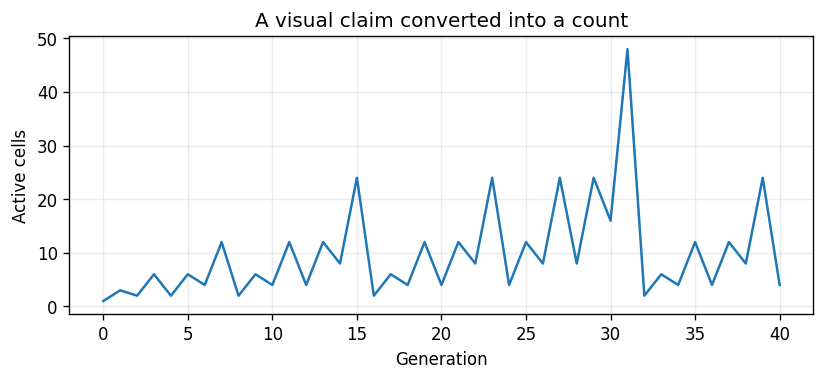

{'initial_active': 1, 'final_active': 4, 'max_active': 48}

In [5]:
active = history.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 3)); ax.plot(active); ax.set(xlabel="Generation", ylabel="Active cells", title="A visual claim converted into a count"); ax.grid(alpha=.25); plt.show()
{"initial_active": int(active[0]), "final_active": int(active[-1]), "max_active": int(active.max())}


## What the evidence supports

A tiny local mechanism can produce structured spacetime history. It does not establish life, agency, robustness, reproduction, or evolution.

## Things to try

Change the rule, boundary size, or initial condition and re-run the measurement.

## Provenance

**Book chapter**

`content/books/digital-life/00-what-is-digital-life/index.md`

**Research scripts used**

- `scripts/books/digital-life/ch02_remove_almost_everything.py`

**Book figures reproduced**

- Methodological chapter; no book figure is directly reproduced.
